<a href="https://colab.research.google.com/github/BlockchainDlamini/COS781_Data_Mining_Project/blob/main/dnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pwd

'/content/drive/MyDrive/COS711/classify_galaxies/dev'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd ./drive/MyDrive/COS711/classify_galaxies/dev

[Errno 2] No such file or directory: './drive/MyDrive/COS711/classify_galaxies/dev'
/content/drive/MyDrive/COS711/classify_galaxies/dev


In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

df = pd.read_csv("../dataset/processed.csv", index_col=0)
df.head()

,modelMag_u,modelMag_z,modelFlux_u,modelFlux_z,petroRad_u,petroRad_g,petroRad_i,petroRad_r,petroRad_z,petroR50_u,...,petroR50_r,petroR50_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z,subclass,redshift,redshift_err
0,21.73818,18.23833,2.007378,50.64961,2.969037,4.252946,3.101782,3.461880,3.071923,1.984029,...,1.638081,1.289375,0.099951,0.311864,0.289370,0.270588,0.187182,1,0.067749,0.000015
1,20.66761,18.04122,5.403369,60.73625,2.186902,2.625105,2.678123,2.594866,3.163450,1.069268,...,1.263937,1.318443,0.366549,0.516876,0.517447,0.552297,0.636966,1,0.105118,0.000010
2,23.63531,18.68396,0.713778,33.58972,1.259084,1.644824,1.801951,1.749696,3.059948,0.663606,...,0.987395,1.612933,0.050000,0.417137,0.506950,0.549881,0.370166,1,0.234089,0.000030
3,20.12374,16.72423,8.920645,204.31610,6.625083,4.719598,4.494591,4.777463,4.636094,3.160263,...,2.156205,2.035692,0.310763,0.356827,0.389345,0.388160,0.416660,1,0.110825,0.000030
5,19.47473,16.89580,16.220930,174.45070,4.734951,4.485415,4.086593,4.275559,4.503903,2.455249,...,1.983631,1.863166,0.754158,0.767767,0.759105,0.742471,0.721491,1,0.111458,0.000011


In [ ]:
# !pip install torch torchvision

In [ ]:
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

sme = SMOTEENN(random_state=42, sampling_strategy=0.6)
under = RandomUnderSampler(sampling_strategy=0.6)
pipeline = Pipeline(steps=[('o', sme), ("u", under)])

X = df.drop("subclass", axis=1).to_numpy()
y = df["subclass"].to_numpy().reshape(-1,1)
print((y==0).sum(), (y==1).sum())
print(X.shape, y.shape)

23960 73518
(97478, 20) (97478, 1)


In [ ]:
model_with_results = []

In [ ]:
from keras.layers import Dense, LayerNormalization, BatchNormalization, Dropout
from keras.models import Sequential
from keras.optimizers import Adam
from keras.initializers import GlorotUniform # to use seeds
from keras.activations import leaky_relu # more parametrisation may be excessive for number of samples
from keras import regularizers
from keras import backend as k
from keras import losses
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow import keras

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
class BaselineOptimizer(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.01, name="BaselineOptimizer", **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.is_first = tf.Variable(True, trainable=False, dtype=tf.bool)

    def build(self, variables):
        super().build(variables)
        self.prev_grads = [self.add_variable_from_reference(ref, "prev_grad") for ref in variables]
        self.accum_neg_g = [self.add_variable_from_reference(
            ref, "accum_neg_g",
            initializer=tf.constant_initializer(0.001)
        ) for ref in variables]
        self.accum_pos_g = [self.add_variable_from_reference(
            ref, "accum_pos_grad",
            initializer=tf.constant_initializer(0.001)
        ) for ref in variables]

        # tf.print("dtype of accum_pos_g_og:", self.accum_pos_g)
        # tf.print("dtype of accum_neg_g_og:", self.accum_neg_g)

    def update_step(self, grad, var, learning_rate):
        grad = tf.cast(grad, var.dtype)
        lr   = tf.cast(learning_rate, var.dtype)
        idx  = self._get_variable_index(var)
        prev_g_og = self.prev_grads[idx]
        prev_g = tf.cast(self.prev_grads[idx], var.dtype)

        def on_first():
            self.is_first.assign(False)
            result_var = var - grad * lr
            return result_var


        new_var = on_first()
        prev_g_og.assign(grad)
        var.assign(new_var)

    def get_config(self):
        return {"name": self.name}

In [ ]:
class PosNegOptimizer(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.009, name="PosNegOptimizer", decay=0.99, c=2e-1, epsilon=1e-2, **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.decay = float(decay) # for moving average i.e. smoothing
        self.base_c = float(c) # baseline constant
        self.epsilon = float(epsilon) # safeguard in denominators

    def build(self, variables):
        super().build(variables)
        self.prev_grads = [self.add_variable_from_reference(ref, "prev_grad") for ref in variables]
        self.accum_neg_g = [self.add_variable_from_reference(
            ref, "accum_neg_g",
            initializer=tf.constant_initializer(10)
        ) for ref in variables]
        self.accum_pos_g = [self.add_variable_from_reference(
            ref, "accum_pos_grad",
            initializer=tf.constant_initializer(10)
        ) for ref in variables]

        # tf.print("dtype of accum_pos_g_og:", self.accum_pos_g)
        # tf.print("dtype of accum_neg_g_og:", self.accum_neg_g)

    # TODO: Exclude bias from update, let it update normally
    def update_step(self, grad, var, learning_rate):
        grad = tf.cast(grad, var.dtype)
        lr   = tf.cast(learning_rate, var.dtype)

        idx  = self._get_variable_index(var)
        prev_g_og = self.prev_grads[idx]
        prev_g = tf.cast(self.prev_grads[idx], var.dtype)

        def on_first():
            result_var = var - grad * lr
            return result_var

        def on_other():
            # cast constants needed
            decay = tf.cast(self.decay, var.dtype)
            zero = tf.constant(0.0, dtype=var.dtype)
            eps = tf.cast(self.epsilon, var.dtype)
            c = tf.cast(self.base_c, var.dtype)
            decay = tf.cast(self.decay, var.dtype)

            accum_pos_g_og = self.accum_pos_g[idx]
            accum_pos_g_var = tf.cast(accum_pos_g_og, var.dtype)
            accum_neg_g_og = self.accum_neg_g[idx]
            accum_neg_g_var = tf.cast(accum_neg_g_og, var.dtype)

            cond_pos = tf.greater(grad, zero)
            accum_pos_g_og.assign(tf.where(cond_pos, decay * accum_pos_g_var + (1.0 - decay) * grad, accum_pos_g_var))
            cond_neg = tf.less(grad, zero)
            accum_neg_g_og.assign(tf.where(cond_neg, decay * accum_neg_g_var + (1.0 - decay) * tf.abs(grad), accum_neg_g_var))

            # Scale confidence ratio by an idea of distance
            pos_confidence = tf.abs(tf.math.log((accum_pos_g_var + eps / (accum_neg_g_var + eps))))
            neg_confidence = tf.abs(tf.math.log((accum_neg_g_var + eps / (accum_pos_g_var + eps))))

            cond_same_pos = tf.logical_and(tf.greater(grad, zero), tf.greater(prev_g, zero))
            cond_same_neg = tf.logical_and(tf.greater(zero, grad), tf.greater(zero, prev_g))
            cond_diff_pos = tf.logical_and(tf.greater(grad, zero), tf.less(prev_g, zero))
            cond_diff_neg = tf.logical_and(tf.less(grad, zero), tf.greater(prev_g, zero))
            neither = ~(cond_same_pos | cond_same_neg | cond_diff_pos | cond_diff_neg)

            pos_confidence = tf.tanh(pos_confidence)
            neg_confidence = tf.tanh(pos_confidence)

            result_var = tf.where(cond_same_pos, var - (lr * (1 + c)) * grad, var)
            result_var = tf.where(cond_same_neg, var - (lr * (1 + c)) * grad, var)
            result_var = tf.where(cond_diff_pos, var - (lr * (1 - c)) * grad, var)
            result_var = tf.where(cond_diff_neg, var - (lr * (1 - c)) * grad, var)

            return result_var

        new_var = tf.cond(tf.equal(self.iterations, 0), on_first, on_other)
        prev_g_og.assign(grad)
        var.assign(new_var)

    def get_config(self):
        return {"name": self.name}

In [ ]:
def define_model(n_input, activation="tanh", kernel_initializer="glorot_normal", lr=0.009):
  model = Sequential()
  # 1031 parameters currently
  # Was 22, 20, 15, 5, 1
  # Then 80, 70, 50, 70, 50, 25, 1 for big models
  model.add(Dense(80, input_dim=n_input, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(70, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(50, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(70, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(50, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(25, activation=activation, kernel_initializer=kernel_initializer))
  model.add(LayerNormalization())
  model.add(Dense(1, activation=activation, kernel_initializer=kernel_initializer))

  optimizer = Adam(learning_rate=lr, beta_1 = 0.6, beta_2 = 0.76)
  model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["mae"])
  model.save_weights("model.weights.h5")
  return model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import precision_recall_fscore_support
import math
import time

In [ ]:
name = "Tanh_Adam_Overfit_tanh_lr009_b1_06_b2076"

In [ ]:
tf.config.run_functions_eagerly(False)
avg_scores_unseen = []
avg_scores_seen = []

std_scores_unseen = []
std_scores_seen = []

avg_time = []

for j in range(2):
  i = 0
  model = define_model(X.shape[1])
  # model = define_model(X.shape[1])
  precisions_unseen = []
  recalls_unseen = []
  f1s_unseen = []
  precisions_seen = []
  recalls_seen = []
  f1s_seen = []
  times = []
  skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=1)
  skf.get_n_splits(X, y)

  for train_idx, test_idx in skf.split(X,y):
    print(f"Processing Fold set {i}")
    fold_start_time = time.time()
    X_train = X[train_idx, :]
    X_test = X[test_idx, :]
    y_train = y[train_idx]
    y_test = y[test_idx]

    # X_train, y_train = sme.fit_resample(X_train, y_train)
    transformer = RobustScaler().fit(X_train)
    X_train = transformer.transform(X_train)
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32).reshape(-1,1)
    y_test = np.array(y_test, dtype=np.float32).reshape(-1,1)

    n_epochs = 25
    batch_size = 5000

    weights = {0:100, 1:70}
    model.fit(X_train, y_train, epochs=n_epochs, class_weight=weights, batch_size=batch_size, verbose=0)


    X_test = transformer.transform(X_test)
    X_test = np.array(X_test, dtype=np.float32)
    y_pred = model.predict(X_test)

    y_pred = (y_pred > 0.5).astype(int)

    precision, recall, f1, sup = precision_recall_fscore_support(y_test, y_pred)
    precisions_unseen.append(precision)
    recalls_unseen.append(recall)
    f1s_unseen.append(f1)

    y_pred = (model.predict(X_train) > 0.5).astype(int)
    precision, recall, f1, sup = precision_recall_fscore_support(y_train, y_pred)
    precisions_seen.append(precision)
    recalls_seen.append(recall)
    f1s_seen.append(f1)

    model.load_weights("model.weights.h5")

    fold_time = time.time() - fold_start_time
    times.append(fold_time)

    i+=1

  avg_precision = np.mean(precisions_unseen, axis=0)
  avg_recall = np.mean(recalls_unseen, axis=0)
  avg_f1_score = np.mean(f1s_unseen, axis=0)
  avg_train_time = float(np.mean(times))

  std_precision = np.std(precisions_unseen, axis=0)
  std_recall = np.std(recalls_unseen, axis=0)
  std_f1_score = np.std(f1s_unseen, axis=0)

  avg_scores_unseen.append([avg_precision, avg_recall, avg_f1_score])
  std_scores_unseen.append([std_precision, std_recall, std_f1_score])

  avg_precision = np.mean(precisions_seen, axis=0).tolist()
  avg_recall = np.mean(recalls_seen, axis=0).tolist()
  avg_f1_score = np.mean(f1s_seen, axis=0).tolist()

  std_precision = np.std(precisions_unseen, axis=0)
  std_recall = np.std(recalls_unseen, axis=0)
  std_f1_score = np.std(f1s_unseen, axis=0)

  avg_scores_seen.append([avg_precision, avg_recall, avg_f1_score])
  std_scores_seen.append([std_precision, std_recall, std_f1_score])



# Avg scores, 0 = precision, 1 = recall, 2 = f1, 3 = total fold time


In [ ]:
avg_scores_seen = np.mean(avg_scores_seen, axis=0)
avg_scores_unseen = np.mean(avg_scores_unseen, axis=0)
std_scores_seen = np.mean(std_scores_seen, axis=0)
std_scores_unseen = np.mean(std_scores_unseen, axis=0)
total_time = np.sum(times)
avg_times = np.mean(times)

In [ ]:
np.savetxt(f"../model/{name}_avg_scores_seen", avg_scores_seen)
np.savetxt(f"../model/{name}_avg_scores_unseen", avg_scores_unseen)
np.savetxt(f"../model/{name}_std_scores_seen", std_scores_seen)
np.savetxt(f"../model/{name}_std_scores_unseen", std_scores_unseen)
np.savetxt(f"../model/{name}_total_time", np.array([total_time]))

In [ ]:
avg_scores_seen

array([0.77680265, 0.92521637])

In [ ]:
avg_scores_unseen

array([0.77224513, 0.92375289])

In [ ]:
std_scores_seen

array([0.02154758, 0.00941704])

In [ ]:
std_scores_unseen

array([0.02154758, 0.00941704])

In [ ]:
total_time

np.float64(86.56881904602051)

In [ ]:
stringlist = []
model.summary(print_fn=lambda x: stringlist.append(x))
short_model_summary = "\n".join(stringlist)
print(short_model_summary)

Model: "sequential_19"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_113 (Dense)               │ (None, 80)             │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_94          │ (None, 80)             │           160 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 70)             │         5,670 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_95          │ (None, 70)             │           140 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼──────────────────

# Heatmap

In [ ]:
def define_model(n_input, activation="tanh", kernel_initializer="glorot_normal", lr=0.009, beta_1=0.9, beta_2=0.96):
    model = Sequential([
        Dense(22, input_dim=n_input, activation=activation, kernel_initializer=kernel_initializer),
        LayerNormalization(),
        Dense(20, activation=activation, kernel_initializer=kernel_initializer),
        LayerNormalization(),
        Dense(15, activation=activation, kernel_initializer=kernel_initializer),
        LayerNormalization(),
        Dense(5, activation=activation, kernel_initializer=kernel_initializer),
        LayerNormalization(),
        Dense(1, activation="sigmoid", kernel_initializer=kernel_initializer)
    ])

    optimizer = Adam(learning_rate=lr, beta_1=beta_1, beta_2=beta_2)
    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

Training with beta1=0.800, beta2=0.900
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training with beta1=0.800, beta2=0.925


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training with beta1=0.800, beta2=0.950


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training with beta1=0.800, beta2=0.974


...

610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training with beta1=0.990, beta2=0.974


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training with beta1=0.990, beta2=0.999


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


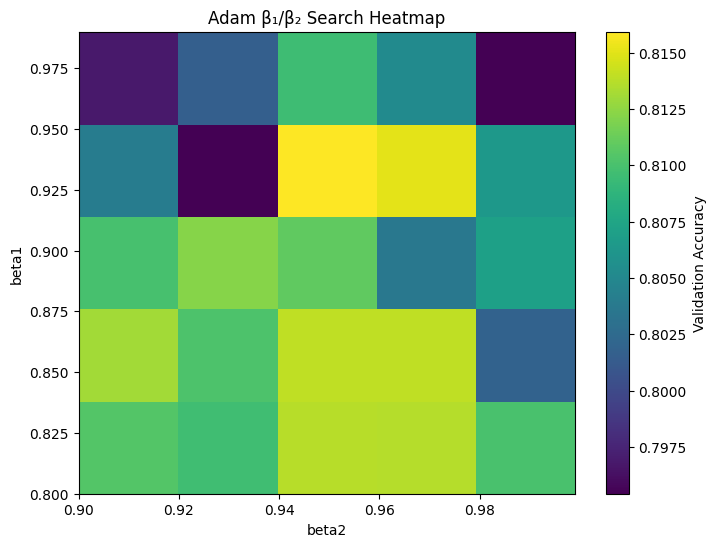

Best: beta_1=0.943, beta_2=0.950, val_acc=0.8159


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

beta1_values = np.linspace(0.8, 0.99, 5)
beta2_values = np.linspace(0.9, 0.999, 5)

results = np.zeros((len(beta1_values), len(beta2_values)))

for i, b1 in enumerate(beta1_values):
    for j, b2 in enumerate(beta2_values):
        print(f"Training with beta1={b1:.3f}, beta2={b2:.3f}")

        model = define_model(X_train.shape[1], beta_1=b1, beta_2=b2)
        history = model.fit(
            X_train, y_train,
            epochs=7,
            batch_size=5000,
            validation_data=(X_val, y_val),
            verbose=0
        )

        y_val_pred = (model.predict(X_val) > 0.5).astype(int)
        val_f1 = f1_score(y_val, y_val_pred, average="macro")
        results[i, j] = val_f1

plt.figure(figsize=(8,6))
plt.imshow(results, origin="lower", cmap="viridis", aspect="auto",
           extent=[beta2_values[0], beta2_values[-1], beta1_values[0], beta1_values[-1]])
plt.colorbar(label="Validation Accuracy")
plt.xlabel("beta2")
plt.ylabel("beta1")
plt.title("Adam β₁/β₂ Search Heatmap")
plt.show()

best_idx = np.unravel_index(np.argmax(results), results.shape)
best_b1 = beta1_values[best_idx[0]]
best_b2 = beta2_values[best_idx[1]]
best_score = results[best_idx]


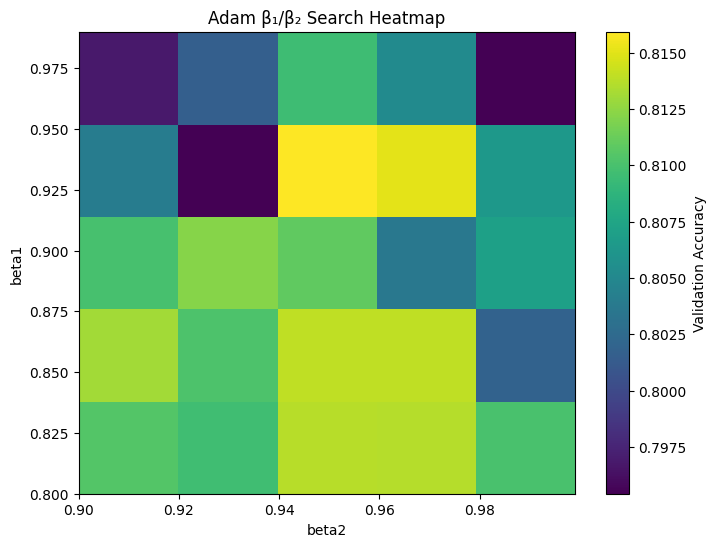

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(results, origin="lower", cmap="viridis", aspect="auto",
           extent=[beta2_values[0], beta2_values[-1], beta1_values[0], beta1_values[-1]])
plt.colorbar(label="Validation Accuracy")
plt.xlabel("beta2")
plt.ylabel("beta1")
plt.title("Adam β₁/β₂ Search Heatmap")
plt.show()

best_idx = np.unravel_index(np.argmax(results), results.shape)
best_b1 = beta1_values[best_idx[0]]
best_b2 = beta2_values[best_idx[1]]
best_score = results[best_idx]

In [ ]:
print(f"Best: beta_1={best_b1:.3f}, beta_2={best_b2:.3f}, val_f1={best_score:.4f}")

Best: beta_1=0.943, beta_2=0.950, val_f1=0.8159
